# 🏆 Predicting Loan Payback - Playground Series S5E11
**Author:** Rishabh Kumar Kannaujiya  
**Date:** Nov 2025

## 1. Introduction
In this notebook, we tackle the **Playground Series Season 5, Episode 11** competition. The goal is to predict the probability of a borrower paying back a loan (Binary Classification).

**Approach:**
1. **EDA & Preprocessing:** Handling missing values, checking imbalance, and encoding categorical features.
2. **Modeling:** Training three Gradient Boosting giants: **XGBoost**, **LightGBM**, and **CatBoost**.
3. **Ensembling:** Combining predictions using a Weighted Average to maximize the **ROC AUC** score.

## 2. Setup and Data Loading

Here we will import the necessary libraries and load the training and testing datasets.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
# ignore the warnings for clean output
warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
submission_df = pd.read_csv('/kaggle/input/playground-series-s5e11/sample_submission.csv')

In [4]:
train_df.shape

(593994, 13)

In [5]:
test_df.shape

(254569, 12)

In [6]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [7]:
train_df.columns.tolist()

['id',
 'annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade',
 'loan_paid_back']

## 3. Exploratory Data Analysis (EDA)
We need to understand the distribution of the target variable and identify any missing data. We also drop the `id` column as it carries no predictive value.

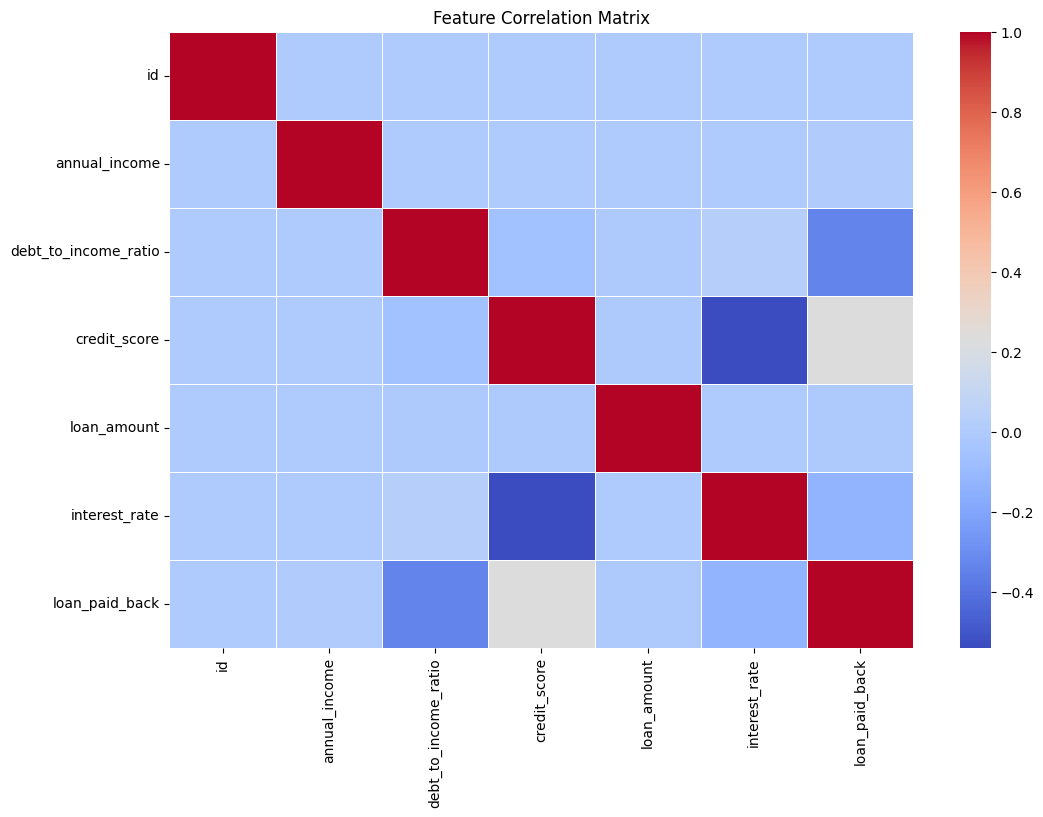

In [8]:
# Correlation Matrix of Numerical Features
plt.figure(figsize=(12, 8))

# Selecting only numerical columns for correlation
numerical_data = train_df.select_dtypes(include=[np.number])
corr = numerical_data.corr()

sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [9]:
target = 'loan_paid_back'
print('Target Distribution:')
train_df[target].value_counts(normalize=True)

Target Distribution:


loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

In [10]:
print('Missing Values in Train:')
train_df.isnull().sum()

Missing Values in Train:


id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [11]:
if 'id' in train_df.columns:
    train_df = train_df.drop(columns=['id'])
    test_df = test_df.drop(columns=['id'])

## 4. Preprocessing
### 4.1 Missing Values
We impute missing values to ensure our models run smoothly:
* **Numerical columns:** Filled with the **Median**.
* **Categorical columns:** Filled with the **Mode** (most frequent value).

In [12]:
cat_cols = [i for i in train_df.columns if train_df[i].dtype == 'object' and i != target]
num_cols = [i for i in train_df.columns if train_df[i].dtype != 'object' and i != target]

In [13]:
print('Categorical Columns:-', cat_cols, '\n\n', 'Number Columns:-', num_cols)

Categorical Columns:- ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade'] 

 Number Columns:- ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']


In [14]:
print('lenght of cat_cols:', len(cat_cols))
print('lenght of num_cols:', len(num_cols))

lenght of cat_cols: 6
lenght of num_cols: 5


In [15]:
for col in num_cols:
    median_value = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_value)
    test_df[col] = test_df[col].fillna(median_value) # To prevent from the data leakage we won't pass the test's median

In [16]:
for col in cat_cols:
    mode_value = train_df[col].mode()
    train_df[col] = train_df[col].fillna(mode_value)
    test_df[col] = test_df[col].fillna(mode_value)

### 4.2 Label Encoding
Machine learning models require numerical input. We will use **Label Encoding** to convert categorical text columns into unique integers.

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
for col in cat_cols:
    le = LabelEncoder()
    combined_data = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined_data)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

train_df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,1.0
1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,0.0
2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,1.0
3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25,1.0
4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,1.0


## 5. Model Training
### 5.1 XGBoost

We start with **XGBoost**, a powerful gradient boosting library known for its performance and speed. We use an 80/20 train-validation split to monitor the **AUC Score**.

In [19]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

In [20]:
X = train_df.drop(columns=[target])
y = train_df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [21]:
xgb_model = XGBClassifier(
    n_estimators=2000,        # Max num of trees
    learning_rate=0.02,       # Lower rate = slower but more accurate
    max_depth=6,              # Each tree Depth
    subsample=0.8,            # Using 80% of rows per tree (It will prevent overfitting)
    colsample_bytree=0.8,     # Using 80% of columns/tree
    random_state=42,
    n_jobs=-1                 # Using all CPU cores
)

In [22]:
print("Training model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    early_stopping_rounds=100, # Stop if validation score doesn't improve for 100 rounds
    verbose=100
)

Training model...
[0]	validation_0-auc:0.90850
[100]	validation_0-auc:0.91385
[200]	validation_0-auc:0.91555
[300]	validation_0-auc:0.91691
[400]	validation_0-auc:0.91807
[500]	validation_0-auc:0.91862
[600]	validation_0-auc:0.91905
[700]	validation_0-auc:0.91932
[800]	validation_0-auc:0.91959
[900]	validation_0-auc:0.91981
[1000]	validation_0-auc:0.92002
[1100]	validation_0-auc:0.92021
[1200]	validation_0-auc:0.92039
[1300]	validation_0-auc:0.92049
[1400]	validation_0-auc:0.92058
[1500]	validation_0-auc:0.92067
[1600]	validation_0-auc:0.92073
[1700]	validation_0-auc:0.92083
[1800]	validation_0-auc:0.92089
[1900]	validation_0-auc:0.92091
[1999]	validation_0-auc:0.92096


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [23]:
xgb_val_preds = xgb_model.predict_proba(X_val)[:, 1] # Taking column: 1 for probability of Positive class
score = roc_auc_score(y_val, xgb_val_preds)
print(f"\nValidation ROC AUC Score: {score:.5f}")


Validation ROC AUC Score: 0.92096


In [24]:
# We need predict_proba, not just 0s and 1s (instead of predict because the metric is ROC AUC)
xgb_test_preds = xgb_model.predict_proba(test_df)[:, 1]

In [25]:
submission_df[target] = xgb_test_preds

submission_df.to_csv('submission_xgb.csv', index=False)

print("Success! 'submission_xgb.csv' created")
print(submission_df.head())

Success! 'submission_xgb.csv' created
       id  loan_paid_back
0  593994        0.935133
1  593995        0.981317
2  593996        0.528695
3  593997        0.912101
4  593998        0.968757


### 5.2 LightGBM

Now, we will train **LightGBM**. It is highly efficient and often captures different patterns than XGBoost, which makes it excellent for ensembling.

In [26]:
from lightgbm import LGBMClassifier
from lightgbm import early_stopping

In [27]:
lgbm_model = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=31,          # unique to LightGBM which will control complexity
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1              # Silent mode
)

In [28]:
print("Training LightGBM...")
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        # Stop if score doesn't improve for 100 rounds
        early_stopping(stopping_rounds=100)
    ]
)

Training LightGBM...
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's auc: 0.922004	valid_0's binary_logloss: 0.244862


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.02, max_depth=6,
               n_estimators=2000, n_jobs=-1, random_state=42, subsample=0.8,
               verbose=-1)

In [29]:
# Validation Score
lgbm_val_preds = lgbm_model.predict_proba(X_val)[:, 1]
score = roc_auc_score(y_val, lgbm_val_preds)
print(f"\nLightGBM Validation ROC AUC: {score:.5f}")


LightGBM Validation ROC AUC: 0.92200


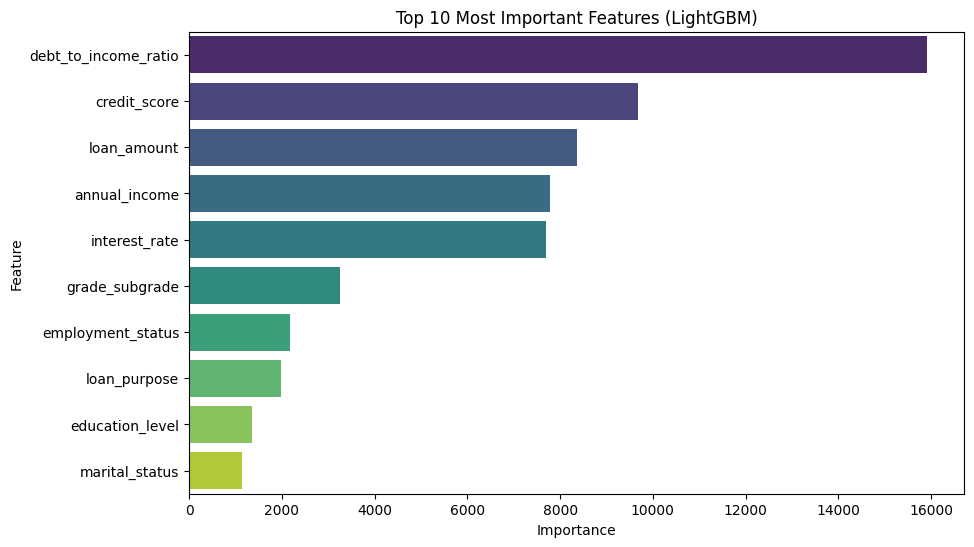

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10), palette='viridis')
plt.title('Top 10 Most Important Features (LightGBM)')
plt.show()

In [31]:
lgbm_test_preds = lgbm_model.predict_proba(test_df)[:, 1]

In [32]:
submission_df[target] = lgbm_test_preds

submission_df.to_csv('submission_lgbm.csv', index=False)

print("Success! 'submission_lgbm.csv' created.")
print(submission_df.head())

Success! 'submission_lgbm.csv' created.
       id  loan_paid_back
0  593994        0.932491
1  593995        0.982140
2  593996        0.583926
3  593997        0.923290
4  593998        0.960394


### 5.3 CatBoost

Now, we will train **CatBoost**. This model is particularly robust and handles categorical relationships very well, often providing high stability.

In [33]:
from catboost import CatBoostClassifier

In [34]:
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.02,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,          # Print progress every 100 trees
    early_stopping_rounds=100
)

In [35]:
print("Training CatBoost...")
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

Training CatBoost...
0:	test: 0.9003430	best: 0.9003430 (0)	total: 116ms	remaining: 3m 52s
100:	test: 0.9109404	best: 0.9109404 (100)	total: 5.49s	remaining: 1m 43s
200:	test: 0.9132113	best: 0.9132113 (200)	total: 10.8s	remaining: 1m 36s
300:	test: 0.9143161	best: 0.9143161 (300)	total: 16.1s	remaining: 1m 30s
400:	test: 0.9151914	best: 0.9151914 (400)	total: 21.4s	remaining: 1m 25s
500:	test: 0.9158588	best: 0.9158588 (500)	total: 26.7s	remaining: 1m 19s
600:	test: 0.9162531	best: 0.9162531 (600)	total: 32s	remaining: 1m 14s
700:	test: 0.9168196	best: 0.9168196 (700)	total: 37.2s	remaining: 1m 8s
800:	test: 0.9174139	best: 0.9174139 (800)	total: 42.4s	remaining: 1m 3s
900:	test: 0.9178237	best: 0.9178237 (900)	total: 47.6s	remaining: 58.1s
1000:	test: 0.9181919	best: 0.9181919 (1000)	total: 52.9s	remaining: 52.8s
1100:	test: 0.9185282	best: 0.9185282 (1100)	total: 58.2s	remaining: 47.5s
1200:	test: 0.9187875	best: 0.9187875 (1200)	total: 1m 3s	remaining: 42.3s
1300:	test: 0.9190650	b

In [36]:
# 3. Check Validation Score
cat_val_preds = cat_model.predict_proba(X_val)[:, 1]
score = roc_auc_score(y_val, cat_val_preds)
print(f"\nCatBoost Validation ROC AUC: {score:.5f}")


CatBoost Validation ROC AUC: 0.92051


In [37]:
cat_test_preds = cat_model.predict_proba(test_df)[:, 1]

submission_df[target] = cat_test_preds
submission_df.to_csv('submission_catboost.csv', index=False)
print("Success! 'submission_catboost.csv' created.")

Success! 'submission_catboost.csv' created.


## 6. Ensembling & Submission
### 6.1 Weighted Ensemble

* To improve generalization and reduce overfitting, we will combine the predictions of all three models.
* Based on validation scores, we assign weights to each model to create the final model prediction.

In [38]:
# Assuming equal weight: 33% XGB + 33% LGBM + 33% CatBoost
ensemble_val_preds = (xgb_val_preds + lgbm_val_preds + cat_val_preds) / 3

In [39]:
# Let's Check if the score improved here
ensemble_score = roc_auc_score(y_val, ensemble_val_preds)
print(f"XGBoost Score:   {roc_auc_score(y_val, xgb_val_preds):.5f}")
print(f"LightGBM Score:  {roc_auc_score(y_val, lgbm_val_preds):.5f}")
print(f"CatBoost Score:  {roc_auc_score(y_val, cat_val_preds):.5f}")
print("-" * 30)
print(f"Ensemble Score:  {ensemble_score:.5f} (Likely the highest! if not then change the parameters in the weighted_val_preds)")

XGBoost Score:   0.92096
LightGBM Score:  0.92200
CatBoost Score:  0.92051
------------------------------
Ensemble Score:  0.92176 (Likely the highest! if not then change the parameters in the weighted_val_preds)


In [40]:
# Weights: LightGBM (0.80), XGBoost (0.10), CatBoost (0.10) Cause ensemble didn't hit the highest
weighted_val_preds = (lgbm_val_preds * 0.80) + (xgb_val_preds * 0.10) + (cat_val_preds * 0.10)

In [41]:
# Let's Check if the score improved here
weighted_ensemble_score = roc_auc_score(y_val, weighted_val_preds)
print(f"XGBoost Score:   {roc_auc_score(y_val, xgb_val_preds):.5f}")
print(f"LightGBM Score:  {roc_auc_score(y_val, lgbm_val_preds):.5f}")
print(f"CatBoost Score:  {roc_auc_score(y_val, cat_val_preds):.5f}")
print("-" * 30)
print(f"Ensemble Score:  {weighted_ensemble_score:.5f} (Likely the highest!)")

XGBoost Score:   0.92096
LightGBM Score:  0.92200
CatBoost Score:  0.92051
------------------------------
Ensemble Score:  0.92203 (Likely the highest!)


In [42]:
# Use below code if it has higher score
# ensemble_test_preds = (test_preds + lgbm_test_preds + cat_test_preds) / 3

#We will use weighted_test_preds for submission as it scored high
weighted_test_preds = (lgbm_test_preds * 0.70) + (xgb_test_preds * 0.15) + (cat_test_preds * 0.15)

In [43]:
# Saving Weighted Submission
submission_df[target] = weighted_test_preds
submission_df.to_csv('submission.csv', index=False)

print("Success! 'submission.csv' created.")

Success! 'submission.csv' created.
